In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

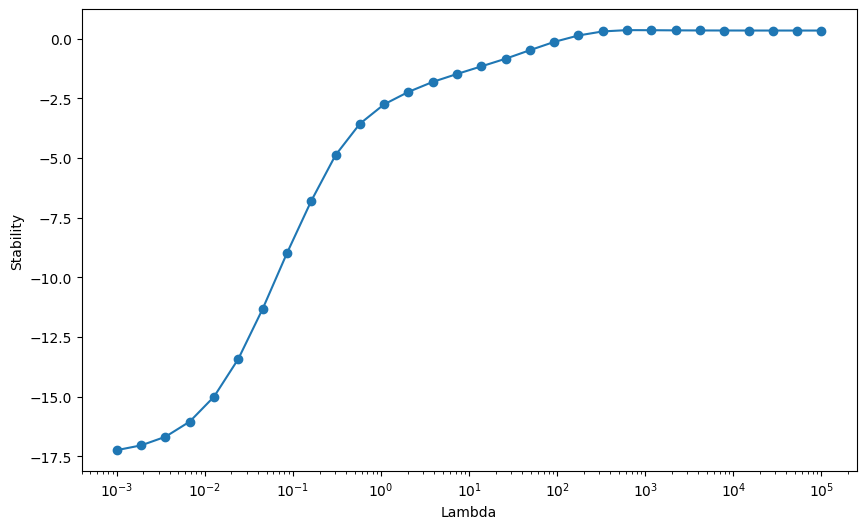

In [45]:
df = pd.read_csv("results/results_synthetic.csv")
plt.figure(figsize=(10, 6))
df = df[df['lambda'] > 0]
plt.plot(df['lambda'].values, np.array(1 - df['instability']), marker='o')
plt.xlabel('Lambda')
plt.ylabel('Stability')
plt.xscale('log')
plt.show()

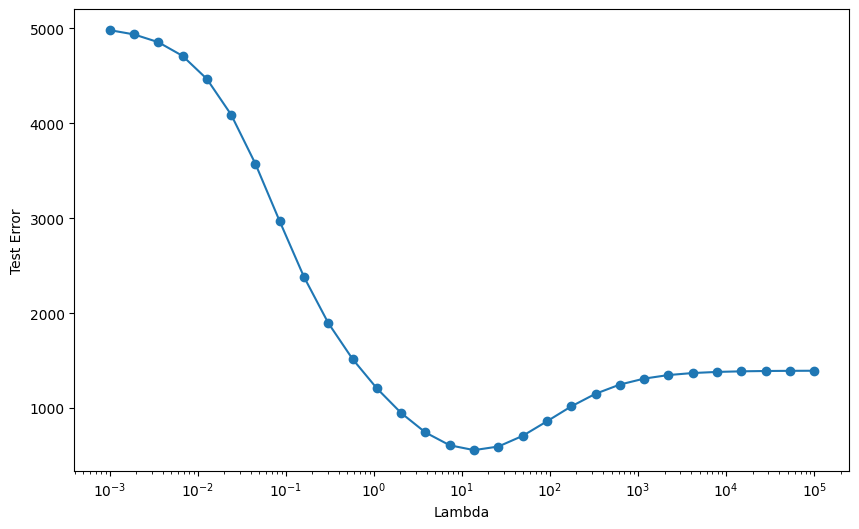

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(df['lambda'].values, df['test_error'].values, marker='o')
plt.xlabel('Lambda')
plt.ylabel('Test Error')
plt.xscale('log')
plt.show()

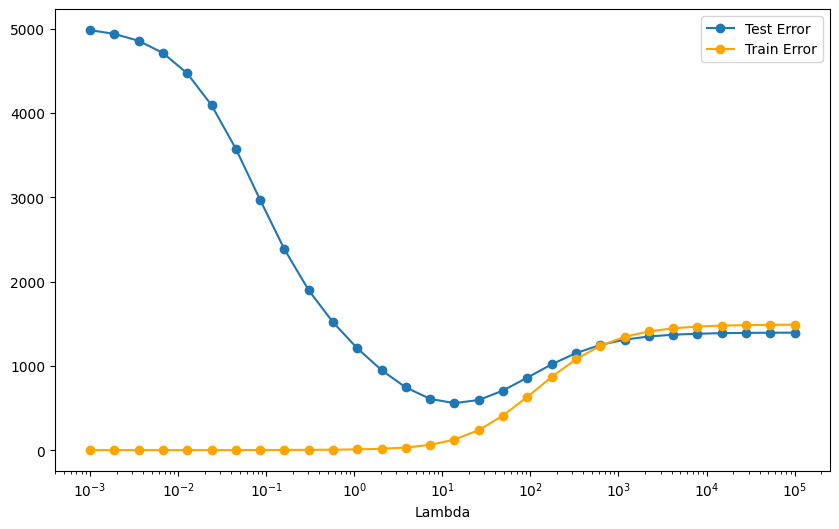

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(df['lambda'].values, df['test_error'].values, marker='o')
plt.plot(df['lambda'].values, df['train_error'].values, marker='o', color='orange')
plt.xlabel('Lambda')
plt.xscale('log')
plt.legend(['Test Error', 'Train Error'])
plt.show()

In [49]:
ols_model = df.iloc[0]

best_ridge_idx = df['test_error'].idxmin()
best_ridge_model = df.iloc[best_ridge_idx]

worst_ridge_model = df.iloc[-1]

medium_idx = best_ridge_idx // 2
medium_ridge_model = df.iloc[medium_idx]

print("--- ANALISI DELL'IMPATTO DI LAMBDA ---")
print(f"1. OLS (No Reg, L=0)          -> Test Error: {ols_model['test_error']:.2f} | Instabilità: {ols_model['instability']:.2f}")
print(f"2. Ridge Medio (L={medium_ridge_model['lambda']:.2f})    -> Test Error: {medium_ridge_model['test_error']:.2f} | Instabilità: {medium_ridge_model['instability']:.2f}")
print(f"3. BEST RIDGE (L={best_ridge_model['lambda']:.2f})     -> Test Error: {best_ridge_model['test_error']:.2f} | Instabilità: {best_ridge_model['instability']:.2f}")
print(f"4. Ridge Pessimo (L={worst_ridge_model['lambda']:.2f}) -> Test Error: {worst_ridge_model['test_error']:.2f} | Instabilità: {worst_ridge_model['instability']:.2f} (UNDERFITTING)")

--- ANALISI DELL'IMPATTO DI LAMBDA ---
1. OLS (No Reg, L=0)          -> Test Error: 32811.49 | Instabilità: 278.46
2. Ridge Medio (L=0.09)    -> Test Error: 2968.87 | Instabilità: 9.99
3. BEST RIDGE (L=13.74)     -> Test Error: 557.07 | Instabilità: 2.17
4. Ridge Pessimo (L=100000.00) -> Test Error: 1393.53 | Instabilità: 0.67 (UNDERFITTING)


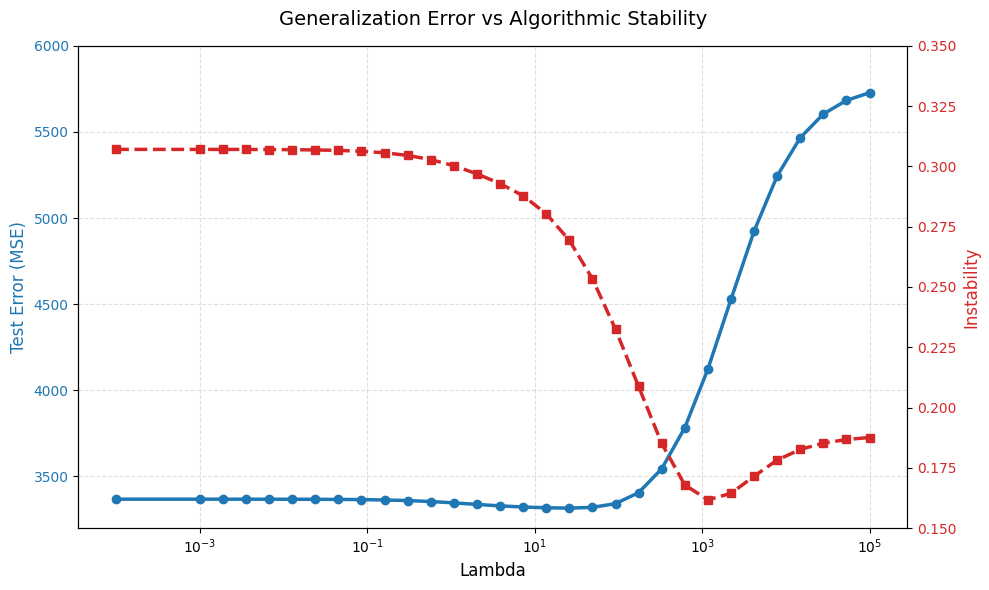

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Caricamento dati
# (Assicurati che il nome del file coincida con quello dove hai salvato i dati reali)
df_diabetes = pd.read_csv('results/results_real.csv')

# Trucco per la scala logaritmica: 
# Sostituiamo temporaneamente lambda=0.0 con 0.0001 (10^-4) solo per il plot
df_diabetes['lambda_plot'] = df_diabetes['lambda'].replace(0.0, 1e-4)

# 2. Creazione della figura
fig, ax1 = plt.subplots(figsize=(10, 6))

# Impostiamo l'asse X in scala logaritmica
ax1.set_xscale('log')
ax1.set_xlabel('Lambda', fontsize=12)

# --- Asse Sinistro: Errore di Test ---
color_error = 'tab:blue'
ax1.set_ylabel('Test Error (MSE)', color=color_error, fontsize=12)
ax1.plot(df_diabetes['lambda_plot'], df_diabetes['test_error'], 
         marker='o', linewidth=2.5, color=color_error, label='Test Error')
ax1.tick_params(axis='y', labelcolor=color_error)

# Stringiamo l'asse Y per enfatizzare la curva a U (il tuo minimo è ~3316)
ax1.set_ylim(3200, 6000) 

# --- Asse Destro: Instabilità ---
ax2 = ax1.twinx()
color_instab = 'tab:red'
ax2.set_ylabel('Instability', color=color_instab, fontsize=12)
ax2.plot(df_diabetes['lambda_plot'], df_diabetes['instability'], 
         marker='s', linestyle='--', linewidth=2.5, color=color_instab, label='Instability')
ax2.tick_params(axis='y', labelcolor=color_instab)

# Diamo respiro all'instabilità (i tuoi valori vanno da 0.16 a 0.30)
ax2.set_ylim(0.15, 0.35)

# Titolo e layout
plt.title('Generalization Error vs Algorithmic Stability', fontsize=14, pad=15)
fig.tight_layout()

# Aggiungiamo una griglia leggera
ax1.grid(True, which="both", ls="--", alpha=0.4)

plt.show()